# 🧠 ET / PD MRI Dataset Preprocessing
**Thesis: AI-013 — Neural network for differential diagnosis of ET and tremor-dominant PD**

This notebook:
1. Reads `metadata.csv` produced by the DICOM→PNG pipeline
2. Remaps stale local paths in `dest_png_path` to the actual Kaggle input directory
3. Extracts ET / PD labels from Russian patient folder names
4. Detects & keeps only axial + sagittal slices
5. Removes blank / uninformative slices
6. Resizes all images to 224×224
7. Splits by **patient** (stratified) → train / val / test
8. Writes organised folders + `manifest.csv` + augmentation config to `/kaggle/working/processed/`

## 📦 Install dependencies

In [1]:
!pip install -q pillow scikit-learn tqdm pandas numpy

## ⚙️ Configuration — edit these before running

In [ ]:
import os

# ── INPUT ──────────────────────────────────────────────────────────────────
# Path to metadata.csv on Kaggle
METADATA_PATH  = '/kaggle/input/datasets/oovamoyo/evans-full-dataset/artifacts/Загрузки/MRT_PNGs/metadata.csv'  # ← change this

# Root folder where the PNG files actually live on Kaggle
# e.g. if your PNGs are at /kaggle/input/my-mri-pngs/artifacts/МРТ_PNGs/...
# set this to '/kaggle/input/my-mri-pngs'
METADATA_PATH   = '/kaggle/input/datasets/oovamoyo/evans-full-dataset/artifacts/Загрузки/MRT_PNGs/metadata.csv'
PNG_KAGGLE_ROOT = '/kaggle/input/datasets/oovamoyo/evans-full-dataset' # ← change this

# ── OUTPUT ─────────────────────────────────────────────────────────────────
OUTPUT_DIR = '/kaggle/working/processed'

# ── PREPROCESSING SETTINGS ─────────────────────────────────────────────────
TARGET_SIZE          = 224
ORIENTATIONS_KEEP    = ['axial', 'sagittal']

# We are keeping the middle 20% of each MRI series
MIDDLE_FRACTION      = 0.20

# ── SPLIT RATIOS ───────────────────────────────────────────────────────────
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
RANDOM_SEED = 42

# ── DRY RUN ────────────────────────────────────────────────────────────────
# True  → analyse dataset, print stats, write nothing (safe sanity check)
# False → run fully and write all output files
DRY_RUN = False

print('Configuration loaded ✓')

Configuration loaded ✓


## 🗺️ Step 0 — Remap stale local paths

The `dest_png_path` column in `metadata.csv` contains absolute paths from the machine
where the DICOM→PNG conversion was originally run (e.g. `/Users/oovamoyo/...`).
Those paths do not exist on Kaggle.

This cell detects the stale path prefix automatically and rewrites every path
to point at the correct location under `PNG_KAGGLE_ROOT`.

In [ ]:
import pandas as pd

metadata =pd.read_csv(METADATA_PATH)

def fix_kaggle_path(mac_path):
    parts = str(mac_path).split('MRT_PNGs/')
    if len(parts) > 1:
        return f"/kaggle/input/datasets/oovamoyo/evans-full-dataset/artifacts/Загрузки/MRT_PNGs/{parts[1]}"
    return mac_path

metadata['dest_png_path'] = metadata['dest_png_path'].apply(fix_kaggle_path)

# Verify
sample_check = metadata[metadata['status'] == 'OK']['dest_png_path'].dropna().head(10)
found = sum(os.path.isfile(p) for p in sample_check)
print(f"Path remap verification (first 10 OK rows):")
print(f"  Files found on disk : {found} / {len(sample_check)}")
if found == len(sample_check):
    print("  ✓ All sample paths resolved correctly — ready to proceed.")
elif found == 0:
    print("  ⛔ No files found. Sample path:", sample_check.iloc[0])
else:
    print(f"  ⚠ {len(sample_check) - found} paths still missing.")
    print("  Sample missing path:", sample_check.iloc[0])

Path remap verification (first 10 OK rows):
  Files found on disk : 10 / 10
  ✓ All sample paths resolved correctly — ready to proceed.


## 🏷️ Label extraction

In [4]:
import re
from typing import Optional

# Keep your explicit overrides for medical edge-cases!
LABEL_OVERRIDES: dict[str, Optional[str]] = {
    'МРТ Ахметова АМ - БП, 3 Тл': 'PD',
    'МРТ Ахметова РВ - ФТД (псих)': None,
    'МРТ Гимазетдинова - БП+дистония': 'PD',
    'МРТ Давыдова ЛЯ - ДТЛ (БП было)': None,
    'МРТ Абдулхакова ГХ - БП с деменцией (ДТЛ)': None,
    'МРТ Гатауллин ЗГ-БП (МСАпод вопросом)': None,
    'МРТ Гильманова НМ - БП (МСА_подвопр)': None,
    # ... (Feel free to paste the rest of your original overrides here)
}

def extract_label(patient_folder: str) -> Optional[str]:
    # 1. Manual Overrides always win (respects your medical inclusion/exclusion choices)
    if patient_folder in LABEL_OVERRIDES:
        return LABEL_OVERRIDES[patient_folder]
        
    folder_upper = patient_folder.upper()
    
    # 2. Strict Comorbidity & Uncertainty Check
    # Drop immediately if "неБП" (not PD) or "вопр" (questionable) is present
    if "НЕБП" in folder_upper.replace(" ", "") or "ВОПР" in folder_upper:
        return None
        
    # 3. Regex Word Boundaries
    # (^|\W) ensures we match the start of the string or a non-word char (space, dash, plus)
    # (\W|$) ensures we match the end of the string or a non-word char
    # This prevents 'АхмЕТова' from triggering 'ЕТ'
    has_pd = bool(re.search(r'(^|\W)(БП|ПД|ПБ)(\W|$)', folder_upper))
    has_et = bool(re.search(r'(^|\W)(ЭТ|ЕТ)(\W|$)', folder_upper))
    
    # 4. Strict Binary Classification (Pure ET or Pure PD)
    if has_pd and has_et:
        return None  # Drop mixed cases (e.g., БП+ЭТ)
    elif has_pd:
        return 'PD'
    elif has_et:
        return 'ET'
        
    # Drop everything else (СК, БА, ХИГМ, ФТД, etc.)
    return None

# ── Sanity Checks ──────────────────────────────────────────────────────────
assert extract_label('МРТ Булатов ЭР - ЭТ') == 'ET'
assert extract_label('МРТ Петров АВ - БП') == 'PD'
assert extract_label('МРТ Ахметова АМ - СК') is None      # Ignore ET in surname
assert extract_label('МРТ Иванов - БП+ЭТ') is None        # Drop comorbidities
assert extract_label('МРТ Сидоров - ХИГМ (неБП)') is None # Drop negated PD
assert extract_label('МРТ Кашапова - БП продрома вопр') is None # Drop questionable

print('Robust Regex Label Extractor ✓')

Robust Regex Label Extractor ✓


In [5]:
unique_folders = metadata['patient_folder'].dropna().unique()
print(f"Total unique patient folders: {len(unique_folders)}\n")
for folder in sorted(unique_folders):
    label = extract_label(folder)
    print(f"  {label or '❓ UNKNOWN':>10}  |  {folder}")

# This will print every patient folder alongside the label the script would assign to it, so you can immediately spot any problems — folders labelled wrong, folders with `UNKNOWN`, or edge cases like that `БП +ЭТ` one.

# The output will look something like:
# ```
# Total unique patient folders: 42

#         ET  |  МРТ Булатов ЭР - ЭТ
#         ET  |  МРТ Иванов - ЭТ
#         PD  |  МРТ Петров БП
#    ❓ UNKNOWN  |  МРТ Сидоров контроль
#         PD  |  БП +ЭТ_Валеева фх-3,0 Тл нигро   ← this one

Total unique patient folders: 226

          PD  |  БП +ЭТ_Валеева фх-3,0 Тл нигросома-1
          PD  |  БП+ОНМК_Нурмухаметов ФН-1,5 Тл - нигросома-1
          PD  |  БП+ЭТ_Трофимова МА-3,0 Тл - нигросома-1
   ❓ UNKNOWN  |  БП_Абросимова ЛА-1,5 Тл без нигросомы-1
   ❓ UNKNOWN  |  БП_Гарафиева ДМ-3,0 Тл - нигросома-1
   ❓ UNKNOWN  |  БП_Павлихин ЛИ-3,0 Тл нигросома-1
   ❓ UNKNOWN  |  БП_Ракипова ГК - 3,0 Тл - нигросома-1
   ❓ UNKNOWN  |  БП_Соловьева РН-3,0 Тл - нигросома-1
   ❓ UNKNOWN  |  БП_Хуснутдинова ГМ-3,0 Тл нигросома-1
   ❓ UNKNOWN  |  МРТ  Габидуллина ИР - гемиспазм справа
          PD  |  МРТ  ИвановВВ - БП
   ❓ UNKNOWN  |  МРТ (ПЭТ) Шипелов ДЕ - ПНП, подтвр
          PD  |  МРТ - Дорохова, БП + усил физ
          PD  |  МРТ Абдуллина ИГ - БП
   ❓ UNKNOWN  |  МРТ Абдулхакова ГХ - БП с деменцией (ДТЛ)
          PD  |  МРТ Абдулхакова ГХ - БП+психотизация
   ❓ UNKNOWN  |  МРТ Абузарова РФ - СК
   ❓ UNKNOWN  |  МРТ Аглямова ЛЮ - СК
          PD  |  МРТ Айтняков ИХ - БП
        

## 🧭 Orientation detection

In [6]:
import ast
import numpy as np

def _parse_triplet(value) -> Optional[np.ndarray]:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    try:
        return np.array([float(x) for x in ast.literal_eval(str(value))])
    except Exception:
        return None

def detect_orientation(row: pd.Series) -> str:
    iop = _parse_triplet(row.get('image_position_patient'))
    if iop is not None and len(iop) == 6:
        normal   = np.cross(iop[:3], iop[3:])
        dominant = int(np.argmax(np.abs(normal)))
        return {0: 'sagittal', 1: 'coronal', 2: 'axial'}[dominant]
    desc = str(row.get('series_description', '')).lower()
    if any(k in desc for k in ['ax', 'tra', 'transverse']): return 'axial'
    if any(k in desc for k in ['sag', 'sagittal']):          return 'sagittal'
    if any(k in desc for k in ['cor', 'coronal']):           return 'coronal'
    return 'unknown'

print('Orientation detector ✓')

Orientation detector ✓


## 🖼️ Blank slice detection & image preprocessing

In [7]:
import warnings
from PIL import Image
import numpy as np

def preprocess_image(src_path: str) -> Optional[Image.Image]:
    try:
        img = Image.open(src_path).convert('L')
    except Exception:
         
        return None
    return img.resize((TARGET_SIZE, TARGET_SIZE), Image.LANCZOS)

def get_middle_fraction(group_df: pd.DataFrame, fraction: float = 0.20) -> pd.DataFrame:
    """
    Sorts the slices anatomically and returns the middle X%.
    """
    # 1. Sort anatomically: use slice_location if available, otherwise instance_number
    if group_df['slice_location'].notna().any():
        group_df = group_df.sort_values(by='slice_location')
    elif group_df['instance_number'].notna().any():
        group_df = group_df.sort_values(by='instance_number')
    else:
        # Absolute fallback if metadata is entirely missing
        group_df = group_df.sort_values(by='dest_png_path')
        
    n_slices = len(group_df)
    if n_slices == 0:
        return group_df
        
    # 2. Calculate the bounds for the middle fraction
    drop_fraction = (1.0 - fraction) / 2.0
    start_idx = int(n_slices * drop_fraction)
    end_idx = int(n_slices * (drop_fraction + fraction))
    
    # Safety net: keep at least 1 slice for very short sequences
    if start_idx == end_idx:
        end_idx = min(start_idx + 1, n_slices)
        
    return group_df.iloc[start_idx:end_idx]

print('Image utilities ✓')

Image utilities ✓


## ✂️ Patient-level stratified split

In [8]:
from sklearn.model_selection import train_test_split

def split_patients(unique_patients_df: pd.DataFrame) -> dict[str, str]:
    pts  = unique_patients_df['patient_folder'].tolist()
    lbls = unique_patients_df['label'].tolist()

    n_et = lbls.count('ET')
    n_pd = lbls.count('PD')
    n_total = len(pts)
    print(f'  Unique patients: {n_total}  (ET={n_et}, PD={n_pd})')

    # Need at least 2 of each class to stratify
    can_stratify = (n_et >= 2 and n_pd >= 2)
    if not can_stratify:
        print('  ⚠  Too few patients per class for stratification — using random split.')

    train_val, test = train_test_split(
        pts, test_size=TEST_RATIO,
        stratify=lbls if can_stratify else None,
        random_state=RANDOM_SEED
    )
    tv_labels = unique_patients_df.set_index('patient_folder').loc[train_val, 'label'].tolist()
    n_et_tv = tv_labels.count('ET')
    n_pd_tv = tv_labels.count('PD')
    can_stratify_tv = (n_et_tv >= 2 and n_pd_tv >= 2)

    train, val = train_test_split(
        train_val, test_size=VAL_RATIO / (1 - TEST_RATIO),
        stratify=tv_labels if can_stratify_tv else None,
        random_state=RANDOM_SEED
    )
    return {p: 'train' for p in train} | {p: 'val' for p in val} | {p: 'test' for p in test}

print('Split utility ✓')

Split utility ✓


## 🚀 Run the full pipeline

In [9]:
import json
from tqdm.notebook import tqdm
from pathlib import Path

print('=' * 60)
print('  ET/PD MRI Dataset Preprocessing Pipeline')
print('=' * 60)

# ── Step 1: Keep OK rows ───────────────────────────────────────────────────
df = metadata[metadata['status'] == 'OK'].copy()
print(f'[1/6] Loaded                   : {len(metadata):,} rows total')
print(f'      Status=OK                : {len(df):,}  (dropped {len(metadata)-len(df):,} errors)')

# ── Step 2: Extract labels ─────────────────────────────────────────────────
df['label'] = df['patient_folder'].apply(extract_label)
unknown = df[df['label'].isna()]['patient_folder'].unique()
if len(unknown):
    print(f'\n  ⚠  {len(unknown)} patient folder(s) could not be labelled → excluded\n')
df = df[df['label'].notna()].copy()
print(f'[2/6] After label extraction   : {len(df):,}  ET={(df["label"]=="ET").sum():,}  PD={(df["label"]=="PD").sum():,}')

if len(df) == 0:
    raise RuntimeError('No labelled rows found.')

# ── Step 3: Orientation filter ─────────────────────────────────────────────
df['orientation'] = df.apply(detect_orientation, axis=1)
print(f'[3/6] Orientation breakdown    : {df["orientation"].value_counts().to_dict()}')
before = len(df)
df = df[df['orientation'].isin(ORIENTATIONS_KEEP)].copy()
print(f'      After orientation filter : {len(df):,}  (dropped {before-len(df):,})')

# ── Step 4: Keep middle fraction of slices per series ─────────────────────
print(f'[4/6] Filtering middle {int(MIDDLE_FRACTION * 100)}% of slices per series ...')
before = len(df)
df = df.groupby(
    ['patient_folder', 'series_instance_uid'], group_keys=False
).apply(lambda g: get_middle_fraction(g, fraction=MIDDLE_FRACTION))
print(f'      Slices removed (peripheral) : {before - len(df):,}')
print(f'      Remaining core brain slices : {len(df):,}')
print(f'      ET={( df["label"]=="ET").sum():,}  PD={(df["label"]=="PD").sum():,}')

# ── Step 5: Balance classes ────────────────────────────────────────────────
# Downsample the majority class (PD) to match the minority class (ET)
n_et = (df['label'] == 'ET').sum()
n_pd = (df['label'] == 'PD').sum()
print(f'\n[5/6] Balancing classes:')
print(f'      Before: ET={n_et:,}  PD={n_pd:,}  (ratio 1:{n_pd/n_et:.1f})')

df_et = df[df['label'] == 'ET']
df_pd = df[df['label'] == 'PD'].sample(n=n_et, random_state=RANDOM_SEED)
df = pd.concat([df_et, df_pd]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f'      After : ET={len(df_et):,}  PD={len(df_pd):,}  (balanced ✓)')

# ── Step 6: Copy & resize images into ET/ and PD/ folders ─────────────────
if not DRY_RUN:
    for label in ['ET', 'PD']:
        os.makedirs(f'{OUTPUT_DIR}/{label}', exist_ok=True)

manifest_rows = []
n_copied  = 0
n_missing = 0

print(f'\n[6/6] {"(DRY RUN) " if DRY_RUN else ""}Processing images ...')
for _, row in tqdm(df.iterrows(), total=len(df), desc='  Processing'):
    src     = row['dest_png_path']
    label   = row['label']
    patient = row['patient_folder']
    orient  = row['orientation']

    safe_patient = ''.join(c if c.isalnum() or c in '-_' else '_' for c in patient)[:40]
    out_name     = f"{safe_patient}__{Path(src).stem}.png"
    dest_rel     = f"{label}/{out_name}"          # ← ET/ or PD/ directly, no split subfolder
    dest_abs     = f"{OUTPUT_DIR}/{dest_rel}"

    manifest_rows.append({
        'path':           dest_rel,
        'abs_path':       dest_abs,
        'label':          label,
        'label_int':      0 if label == 'ET' else 1,
        'patient_id':     patient,
        'orientation':    orient,
        'src_path':       src,
        'slice_location': row.get('slice_location'),
        'rows':           row.get('rows'),
        'cols':           row.get('cols'),
    })

    if not DRY_RUN:
        img = preprocess_image(src)
        if img is None:
            n_missing += 1
            continue
        img.save(dest_abs, format='PNG', compress_level=3)
        n_copied += 1

# ── Save manifest ──────────────────────────────────────────────────────────
manifest_df = pd.DataFrame(manifest_rows)

if not DRY_RUN:
    manifest_df.to_csv(f'{OUTPUT_DIR}/manifest.csv', index=False)
    report = {
        'total_slices':    len(manifest_df),
        'unique_patients': int(manifest_df['patient_id'].nunique()),
        'by_label':        manifest_df['label'].value_counts().to_dict(),
        'orientations':    manifest_df['orientation'].value_counts().to_dict(),
        'target_size':     f'{TARGET_SIZE}x{TARGET_SIZE}',
        'files_copied':    n_copied,
        'files_skipped':   n_missing,
        'balanced':        True,
    }
    with open(f'{OUTPUT_DIR}/preprocessing_report.json', 'w') as f:
        json.dump(report, f, indent=2)
    print(f'\nManifest → {OUTPUT_DIR}/manifest.csv  ({len(manifest_df):,} rows)')
    print(f'Report   → {OUTPUT_DIR}/preprocessing_report.json')
else:
    print(f'\nDRY RUN — {len(manifest_df):,} slices would be written.')

print(f"\n{'='*60}")
print('  SUMMARY')
print(f"{'='*60}")
for label in ['ET', 'PD']:
    count = (manifest_df['label'] == label).sum()
    print(f'  {label}  →  {count:,} slices')
print(f'  Total  →  {len(manifest_df):,} slices  (balanced ✓)')
print(f'\n  Output structure:')
print(f'    {OUTPUT_DIR}/')
print(f'    ├── ET/   ({(manifest_df["label"]=="ET").sum():,} images)')
print(f'    ├── PD/   ({(manifest_df["label"]=="PD").sum():,} images)')
print(f'    └── manifest.csv')
print()

  ET/PD MRI Dataset Preprocessing Pipeline
[1/6] Loaded                   : 646,628 rows total
      Status=OK                : 626,842  (dropped 19,786 errors)

  ⚠  91 patient folder(s) could not be labelled → excluded

[2/6] After label extraction   : 408,875  ET=43,250  PD=365,625
[3/6] Orientation breakdown    : {'unknown': 206995, 'axial': 117306, 'sagittal': 54786, 'coronal': 29788}
      After orientation filter : 172,092  (dropped 236,783)
[4/6] Filtering middle 20% of slices per series ...
      Slices removed (peripheral) : 137,627
      Remaining core brain slices : 34,465
      ET=5,260  PD=29,205

[5/6] Balancing classes:
      Before: ET=5,260  PD=29,205  (ratio 1:5.6)
      After : ET=5,260  PD=5,260  (balanced ✓)

[6/6] Processing images ...


/tmp/ipykernel_17/290671661.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(lambda g: get_middle_fraction(g, fraction=MIDDLE_FRACTION))


  Processing:   0%|          | 0/10520 [00:00<?, ?it/s]


Manifest → /kaggle/working/processed/manifest.csv  (10,520 rows)
Report   → /kaggle/working/processed/preprocessing_report.json

  SUMMARY
  ET  →  5,260 slices
  PD  →  5,260 slices
  Total  →  10,520 slices  (balanced ✓)

  Output structure:
    /kaggle/working/processed/
    ├── ET/   (5,260 images)
    ├── PD/   (5,260 images)
    └── manifest.csv



## 📊 Visual sanity check — sample slices per class

KeyError: 'split'

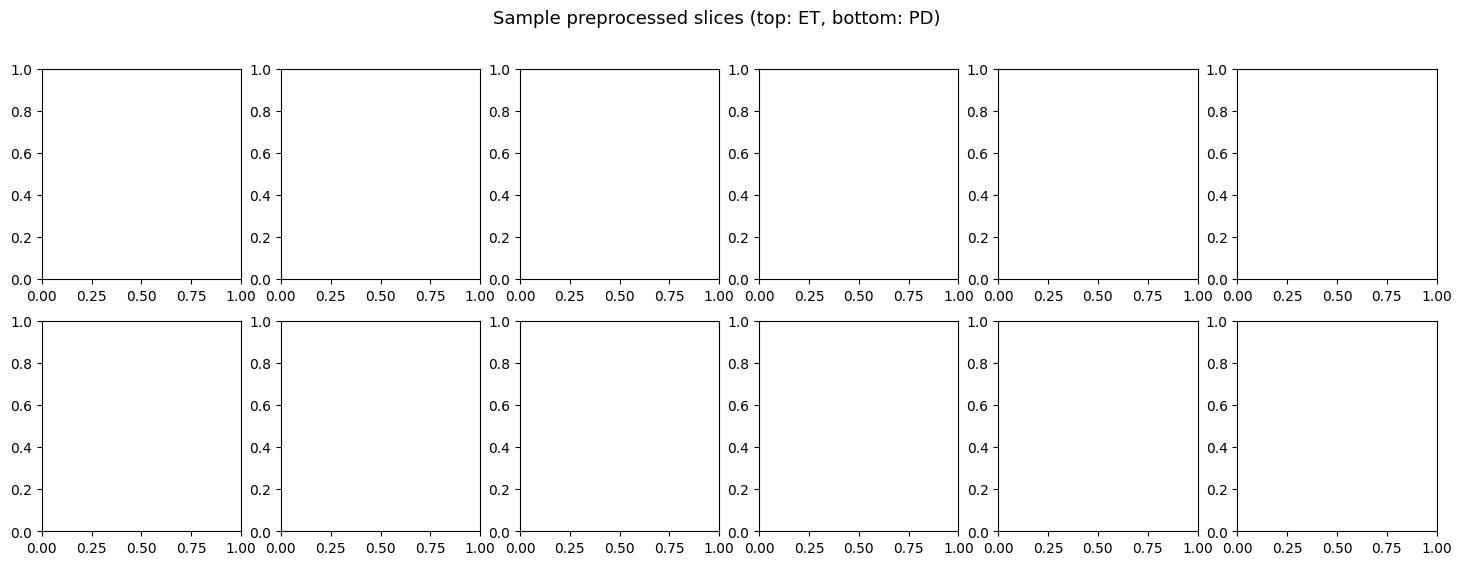

In [10]:
import matplotlib.pyplot as plt

if not DRY_RUN and len(manifest_df) > 0:
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    fig.suptitle('Sample preprocessed slices (top: ET, bottom: PD)', fontsize=13)

    for row_i, label in enumerate(['ET', 'PD']):
        pool = manifest_df[(manifest_df['label'] == label) & (manifest_df['split'] == 'train')]
        samples = pool.sample(min(6, len(pool)), random_state=42)
        for col_i, (_, s) in enumerate(samples.iterrows()):
            ax = axes[row_i, col_i]
            try:
                ax.imshow(Image.open(s['abs_path']).convert('L'), cmap='gray', vmin=0, vmax=255)
            except Exception:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
            ax.set_title(f"{label} | {s['orientation']}", fontsize=8)
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/sample_slices.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Skipping visual check (dry run or empty dataset).')

## ✅ Output structure

```
processed/
├── train/ ET/  PD/
├── val/   ET/  PD/
├── test/  ET/  PD/
├── manifest.csv               ← path, label_int, split, patient_id, orientation
├── augmentation_config.json   ← copy-paste torchvision transforms
├── preprocessing_report.json
└── sample_slices.png
```

**Next step:** Save this notebook output as a new Kaggle dataset, then load `manifest.csv` in your training notebook.

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

print("Hunting for slices the script considers 'blank'...")

# Grab a random sample of OK rows from the original metadata
sample_pool = metadata[metadata['status'] == 'OK'].sample(5000, random_state=42)
blank_images_found = []

for _, row in sample_pool.iterrows():
    path = row['dest_png_path']
    if os.path.isfile(path):
        try:
            img = Image.open(path).convert('L')
            arr = np.array(img, dtype=np.float32)
            
            # The exact same logic from your pipeline
            if float(arr.std()) < 5.0 or float(arr.mean()) < 10.0:
                blank_images_found.append((img, arr.mean(), arr.std()))
        except Exception:
            continue
            
    # Stop once we find 10 blank images to look at
    if len(blank_images_found) >= 10:
        break

# Plot the trash!
if blank_images_found:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Sanity Check: Images flagged as BLANK (Destined for the trash)', fontsize=16)
    
    for ax, (img, mean, std) in zip(axes.flatten(), blank_images_found):
        ax.imshow(img, cmap='gray', vmin=0, vmax=255) # vmin/vmax ensures true black rendering
        ax.set_title(f"Mean: {mean:.1f} | Std: {std:.1f}", fontsize=10)
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print("No blank images found in this sample!")